In this notebook, first few runs didn't use manual group splitting thus producing inaccurate results. We ledt them ti demonstrate the full work completed and for comparison purposes. 

Only the final run starting from run [48] represents the final results with proper data preprocessing.

In [30]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
data = pd.read_csv("merged_dataset.csv")
df = pd.DataFrame(data)
df.head()

,text,label,source
0,"Freemasonry is a fraternity, or a social organ...",1,HC3_reddit_eli5
1,"Summer break: a time of peace, relaxation, and...",0,DAIGT_v2
2,You 're 5 so I 'm going to lay this out simply...,0,HC3_reddit_eli5
3,It's not uncommon for blood pressure to fluctu...,1,HC3_medicine
4,Snow can make the world feel quieter because i...,1,HC3_reddit_eli5


In [9]:
X = df['text']
y = df['label']

# 1st split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2nd split: 30% temp into 2/3 (20% of original) for validation and 1/3 (10% of original) for testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

print("\n--- Data Split ---")
print(f"Training set size:   {len(X_train)} ({len(X_train)/len(df):.0%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df):.0%})")
print(f"Test set size:       {len(X_test)} ({len(X_test)/len(df):.0%})")


--- Data Split ---
Training set size:   86936 (70%)
Validation set size: 24839 (20%)
Test set size:       12420 (10%)


In [11]:
# pipeline chains the TF-IDF vectorizer and the Logistic Regression classifier.
# GridSearchCV will tune the parameters of the components of this pipeline.
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('clf', LogisticRegression(random_state=42, solver='liblinear')),
])

In [12]:
#parameter Grid for GridSearchCVfor both the 'tfidf' and 'clf' steps of the pipeline.
param_grid = {
    'tfidf__max_features': [15000, 25000, 35000],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

In [13]:
# set up 
# 5-fold cross-validation on training data.
# verbose=2 for more detailed output during the search.
# n_jobs=-1 for all available CPU cores - speed
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

print("\nStarting hyperparameter tuning with GridSearchCV...")
start_time = time.time()
# The grid search is performed on the training set only
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"GridSearchCV finished in {end_time - start_time:.2f} seconds.")


Starting hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV finished in 264.24 seconds.


In [14]:
print("\n--- Hyperparameter Tuning Results ---")
print("Best parameters found:")
print(grid_search.best_params_)

# Display timing and scores for each configuration
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nDetailed results for each parameter combination:")
print(results_df[[
    'param_tfidf__max_features', 'param_clf__C', 'param_clf__penalty',
    'mean_fit_time', 'mean_score_time', 'mean_test_score'
]].rename(columns={
    'param_tfidf__max_features': 'max_features',
    'param_clf__C': 'C',
    'param_clf__penalty': 'penalty',
    'mean_fit_time': 'Avg Train Time (s)',
    'mean_score_time': 'Avg Inference Time (s)',
    'mean_test_score': 'CV Accuracy'
}).sort_values(by='CV Accuracy', ascending=False))


--- Hyperparameter Tuning Results ---
Best parameters found:
{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 35000}

Detailed results for each parameter combination:
    max_features     C penalty  Avg Train Time (s)  Avg Inference Time (s)  \
17         35000  10.0      l2           29.813106                2.505081   
16         25000  10.0      l2           30.574831                2.848503   
15         15000  10.0      l2           37.378737                3.274502   
14         35000  10.0      l1           38.301173                3.765760   
13         25000  10.0      l1           36.968108                3.975880   
12         15000  10.0      l1           38.251026                3.287785   
11         35000   1.0      l2           37.194658                3.774639   
10         25000   1.0      l2           37.987446                3.667491   
9          15000   1.0      l2           38.955867                3.574296   
6          15000   1.0      l1           


--- Final Model Performance ---
Training Set Accuracy:   0.9919
Validation Set Accuracy: 0.9607
Test Set Accuracy:       0.9661

Classification Report (Test Set):
                precision    recall  f1-score   support

    Human Text       0.97      0.98      0.97      8046
Generated Text       0.96      0.94      0.95      4374

      accuracy                           0.97     12420
     macro avg       0.96      0.96      0.96     12420
  weighted avg       0.97      0.97      0.97     12420


Confusion Matrix (Test Set):


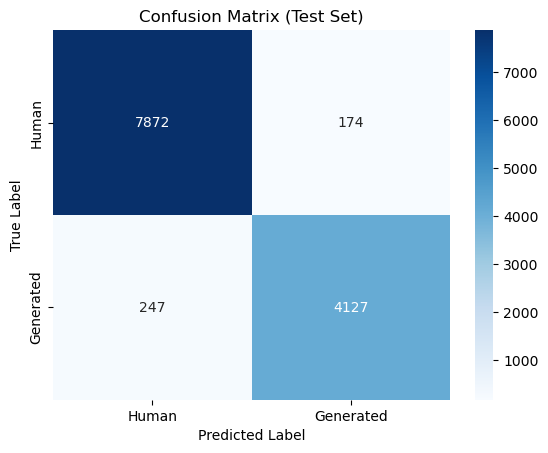

In [15]:
# evaluating the best model ---
# best_estimator_ is the pipeline with the optimal parameters found.
best_model = grid_search.best_estimator_

# accuracy on all three data splits
train_accuracy = best_model.score(X_train, y_train)
val_accuracy = best_model.score(X_val, y_val)
test_accuracy = best_model.score(X_test, y_test)

print("\n--- Final Model Performance ---")
print(f"Training Set Accuracy:   {train_accuracy:.4f}")
print(f"Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Test Set Accuracy:       {test_accuracy:.4f}")

# predictions on the test set for more metrics
y_test_pred = best_model.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Human Text', 'Generated Text']))

print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'Generated'], yticklabels=['Human', 'Generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

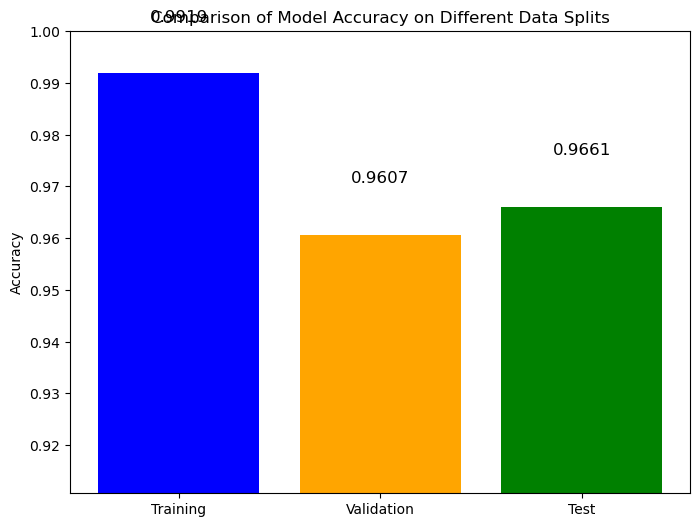

In [17]:
# visualize the difference between train, validation, and test performance.
# results are too good for Logistic Regression
accuracies = {
    'Training': train_accuracy,
    'Validation': val_accuracy,
    'Test': test_accuracy
}

plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracy on Different Data Splits')
plt.ylim([min(accuracies.values()) - 0.05, 1.0])
for i, (key, value) in enumerate(accuracies.items()):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center', fontsize=12)
plt.show()

In [24]:
#Testing custom Sentences ---
print("\n--- Testing Model Inference on New Sentences ---")

# list of sentences to test
sentences_to_test = [
    "You don’t need to completely avoid using your credit card to improve your debt-to-income ratio; what actually matters is lowering your monthly debt payments. If your credit card balance is paid in full each month, your DTI won’t be affected, so normal use is fine. But if you tend to carry a balance, limiting credit card spending can help reduce your minimum payments over time, which directly improves your DTI.", # Likely Human
    "Purpose: Used to tune the model's hyperparameters (settings not learned during training, like learning rate, number of layers, or regularization strength) and for model selection (e.g., deciding the optimal number of training epochs).", # Likely Generated
    "ts all about fucking around and findout what, that debian wont give tho some debian distros are pretty good on itself, nix and arch is flexible for ricing.", # Likely Human
    "The underlying architecture of the system is predicated on a decentralized, blockchain-based ledger for enhanced security.", # Likely Generated
    "Linux ricing is all about customizing your Linux desktop to reflect your personal aesthetic and workflow, turning a standard environment into something uniquely yours. It often involves tweaking window managers, themes, icons, fonts, and system behavior to achieve a clean, efficient, or visually striking setup. While some people rice for pure visual flair and others for productivity, the process itself becomes a creative hobby—one that blends technical tinkering with design. In the end, ricing isn’t just about making your system look good; it’s about building a setup that feels right every time you sit down to use it.", # Likely Human
    "I think ricing is not done by watching a 'complete linux ricing guide'. You see a lock screen in r/unixporn and the comments will say it's hyprlock. Now you'll install hyprlock but the default version sucks ass. So you copy the config files from the guy. Turns out he added some dependencies like fonts and icons that you too need to get. You'll do all these and actually get a lockscreen pretty similar. Now you think to yourself the current one isn't actually how i want it to be you now actually read the config fike and search what the various variables do. You tinker with them a lot and will eventually be satisfied. Rinse and repeat.", # Clearly Generated
]

# best model (pipeline) to predict labels and probabilities
predictions = best_model.predict(sentences_to_test)
probabilities = best_model.predict_proba(sentences_to_test)

# numeric labels to human-readable names
label_map = {0: 'Human Text', 1: 'Generated Text'}

# results
for i, sentence in enumerate(sentences_to_test):
    predicted_label = label_map[predictions[i]]
    confidence_human = probabilities[i][0]
    confidence_generated = probabilities[i][1]
    
    print(f"\nText: \"{sentence}\"")
    print(f"  -> Predicted Label: {predicted_label}")
    print(f"     Confidence Scores: [Human: {confidence_human:.2%}] [Generated: {confidence_generated:.2%}]")


--- Testing Model Inference on New Sentences ---

Text: "You don’t need to completely avoid using your credit card to improve your debt-to-income ratio; what actually matters is lowering your monthly debt payments. If your credit card balance is paid in full each month, your DTI won’t be affected, so normal use is fine. But if you tend to carry a balance, limiting credit card spending can help reduce your minimum payments over time, which directly improves your DTI."
  -> Predicted Label: Human Text
     Confidence Scores: [Human: 65.66%] [Generated: 34.34%]

Text: "Purpose: Used to tune the model's hyperparameters (settings not learned during training, like learning rate, number of layers, or regularization strength) and for model selection (e.g., deciding the optimal number of training epochs)."
  -> Predicted Label: Generated Text
     Confidence Scores: [Human: 44.73%] [Generated: 55.27%]

Text: "ts all about fucking around and findout what, that debian wont give tho some debian d

**The model above demonstrated weak abilities to discriminate between custom human and AI generated text. The accuracies are suspiciously high, because of data leakage. In the next attempt we tried to apply shuffling technique.**

In [36]:
data = pd.read_csv("merged_dataset.csv")
df = pd.DataFrame(data)
df.head()

,text,label,source
0,"Freemasonry is a fraternity, or a social organ...",1,HC3_reddit_eli5
1,"Summer break: a time of peace, relaxation, and...",0,DAIGT_v2
2,You 're 5 so I 'm going to lay this out simply...,0,HC3_reddit_eli5
3,It's not uncommon for blood pressure to fluctu...,1,HC3_medicine
4,Snow can make the world feel quieter because i...,1,HC3_reddit_eli5


In [37]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDataFrame shuffled.")


DataFrame shuffled.


In [38]:
X = df['text']
y = df['label']

# 1st split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2nd split: 30% temp into 2/3 (20% of original) for validation and 1/3 (10% of original) for testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

print("\n--- Data Split ---")
print(f"Training set size:   {len(X_train)} ({len(X_train)/len(df):.0%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df):.0%})")
print(f"Test set size:       {len(X_test)} ({len(X_test)/len(df):.0%})")


--- Data Split ---
Training set size:   86936 (70%)
Validation set size: 24839 (20%)
Test set size:       12420 (10%)


In [39]:
# 5-fold cross-validation 
# verbose=2 same as before
# n_jobs=-1 same as before
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

print("\nStarting hyperparameter tuning with GridSearchCV...")
start_time = time.time()
# The grid search is performed on the training set only
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"GridSearchCV finished in {end_time - start_time:.2f} seconds.")


Starting hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV finished in 262.14 seconds.


In [40]:
print("\n--- Hyperparameter Tuning Results ---")
print("Best parameters found:")
print(grid_search.best_params_)

# timing and scores for each config
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nDetailed results for each parameter combination:")
print(results_df[[
    'param_tfidf__max_features', 'param_clf__C', 'param_clf__penalty',
    'mean_fit_time', 'mean_score_time', 'mean_test_score'
]].rename(columns={
    'param_tfidf__max_features': 'max_features',
    'param_clf__C': 'C',
    'param_clf__penalty': 'penalty',
    'mean_fit_time': 'Avg Train Time (s)',
    'mean_score_time': 'Avg Inference Time (s)',
    'mean_test_score': 'CV Accuracy'
}).sort_values(by='CV Accuracy', ascending=False))


--- Hyperparameter Tuning Results ---
Best parameters found:
{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 35000}

Detailed results for each parameter combination:
    max_features     C penalty  Avg Train Time (s)  Avg Inference Time (s)  \
17         35000  10.0      l2           32.763097                2.482132   
16         25000  10.0      l2           33.458453                2.993630   
15         15000  10.0      l2           40.893341                3.423285   
14         35000  10.0      l1           40.529813                4.230471   
13         25000  10.0      l1           40.374595                4.238876   
12         15000  10.0      l1           37.717660                3.267792   
11         35000   1.0      l2           35.453910                3.982906   
10         25000   1.0      l2           34.872790                3.822341   
9          15000   1.0      l2           34.724154                3.259239   
6          15000   1.0      l1           


--- Final Model Performance ---
Training Set Accuracy:   0.9917
Validation Set Accuracy: 0.9636
Test Set Accuracy:       0.9613

Classification Report (Test Set):
                precision    recall  f1-score   support

    Human Text       0.96      0.98      0.97      8046
Generated Text       0.96      0.93      0.94      4374

      accuracy                           0.96     12420
     macro avg       0.96      0.95      0.96     12420
  weighted avg       0.96      0.96      0.96     12420


Confusion Matrix (Test Set):


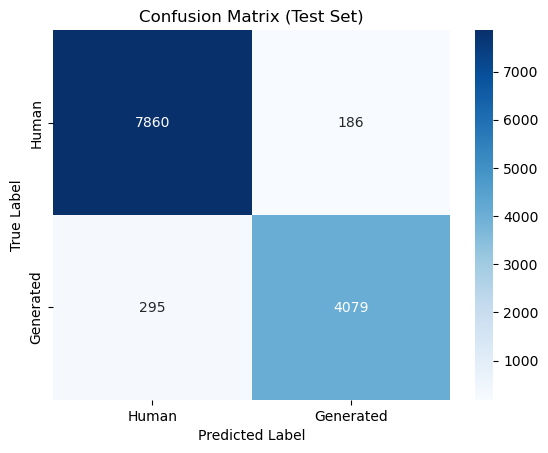

In [41]:
# best_estimator_ is the pipeline with the optimal parameters
best_model = grid_search.best_estimator_

# accuracy on all three data splits (same code)
train_accuracy = best_model.score(X_train, y_train)
val_accuracy = best_model.score(X_val, y_val)
test_accuracy = best_model.score(X_test, y_test)

print("\n--- Final Model Performance ---")
print(f"Training Set Accuracy:   {train_accuracy:.4f}")
print(f"Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Test Set Accuracy:       {test_accuracy:.4f}")

# predictions on the test set for detailed metrics
y_test_pred = best_model.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Human Text', 'Generated Text']))

print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'Generated'], yticklabels=['Human', 'Generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

First attempt of manual group splitting, but the test train validation split was not balanced, since in the first attempt we didn't split the DAIGT_v2 into subgroups. Validation set is too large, test set too small here

In [42]:
train_sources_list = [
    'HC3_reddit_eli5',
    'HC3_open_qa',
    'HC3_medicine',
    'HC3_wiki_csai'
]
validation_sources_list = ['DAIGT_v2']
test_sources_list = ['HC3_finance']

In [43]:
train_df = df[df['source'].isin(train_sources_list)]
val_df = df[df['source'].isin(validation_sources_list)]
test_df = df[df['source'].isin(test_sources_list)]

# final X and y sets
X_train, y_train = train_df['text'], train_df['label']
X_val, y_val = val_df['text'], val_df['label']
X_test, y_test = test_df['text'], test_df['label']

# Verification
print("\nVerifying that sources do not overlap between splits:")
print(f"Overlap between train and validation: {len(set(train_sources_list).intersection(set(validation_sources_list)))}")
print(f"Overlap between validation and test: {len(set(validation_sources_list).intersection(set(test_sources_list)))}")
print(f"Overlap between train and test: {len(set(train_sources_list).intersection(set(test_sources_list)))}")

print("\n--- Final Data Split Sizes ---")
print(f"Training set size:   {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df):.1%})")
print(f"Test set size:       {len(X_test)} ({len(X_test)/len(df):.1%})")



Verifying that sources do not overlap between splits:
Overlap between train and validation: 0
Overlap between validation and test: 0
Overlap between train and test: 0

--- Final Data Split Sizes ---
Training set size:   70938 (57.1%)
Validation set size: 44864 (36.1%)
Test set size:       8393 (6.8%)


In [44]:
param_grid = {
    'tfidf__max_features': [15000, 25000, 35000],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1
)
print("\nStarting hyperparameter tuning with GridSearchCV on properly split data...")
total_start_time = time.time()
grid_search.fit(X_train, y_train)
total_end_time = time.time()
print(f"\nGridSearchCV finished in {total_end_time - total_start_time:.2f} seconds.")



Starting hyperparameter tuning with GridSearchCV on properly split data...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

GridSearchCV finished in 141.95 seconds.


In [45]:
print("\n--- Hyperparameter Tuning Results ---")
print("Best parameters found on the training set:")
print(grid_search.best_params_)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    'param_tfidf__max_features', 'param_clf__C', 'param_clf__penalty',
    'mean_fit_time', 'mean_score_time', 'mean_test_score'
]].rename(columns={
    'param_tfidf__max_features': 'max_features',
    'param_clf__C': 'C',
    'param_clf__penalty': 'penalty',
    'mean_fit_time': 'Avg Train Time (s)',
    'mean_score_time': 'Avg Inference Time (s)',
    'mean_test_score': 'Cross-Val Accuracy'
}).sort_values(by='Cross-Val Accuracy', ascending=False)
print("\n--- Detailed Performance for Each Hyperparameter Configuration ---")
print(results_df)


--- Hyperparameter Tuning Results ---
Best parameters found on the training set:
{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 35000}

--- Detailed Performance for Each Hyperparameter Configuration ---
    max_features     C penalty  Avg Train Time (s)  Avg Inference Time (s)  \
17         35000  10.0      l2           16.456474                1.159133   
16         25000  10.0      l2           16.753401                1.314318   
15         15000  10.0      l2           20.741776                1.600052   
14         35000  10.0      l1           21.728265                1.659765   
13         25000  10.0      l1           21.367590                1.851132   
12         15000  10.0      l1           21.528001                1.598614   
10         25000   1.0      l2           20.140108                2.080373   
11         35000   1.0      l2           20.243332                1.989113   
9          15000   1.0      l2           19.680720                1.577790   
6  

In [46]:
best_model = grid_search.best_estimator_
train_accuracy = best_model.score(X_train, y_train)
val_accuracy = best_model.score(X_val, y_val)
test_accuracy = best_model.score(X_test, y_test)

print("\n--- Final Performance of the Best Model ---")
print(f"Training Set Accuracy:   {train_accuracy:.4f}")
print(f"Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Test Set Accuracy:       {test_accuracy:.4f}  <-- This is your most important score!")


--- Final Performance of the Best Model ---
Training Set Accuracy:   0.9941
Validation Set Accuracy: 0.7097
Test Set Accuracy:       0.8747  <-- This is your most important score!



Classification Report (Test Set):
                precision    recall  f1-score   support

    Human Text       0.83      0.92      0.87      3933
Generated Text       0.93      0.83      0.88      4460

      accuracy                           0.87      8393
     macro avg       0.88      0.88      0.87      8393
  weighted avg       0.88      0.87      0.87      8393


Confusion Matrix (Test Set):


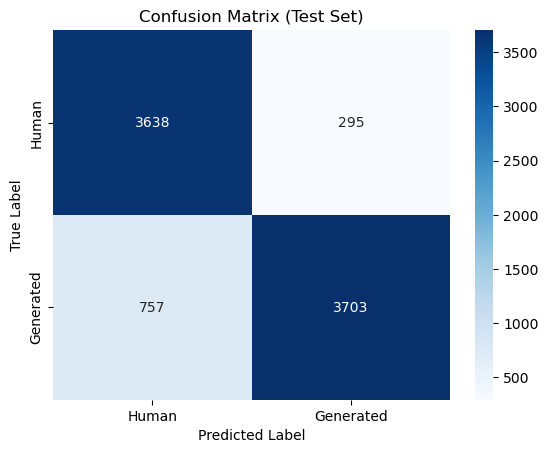

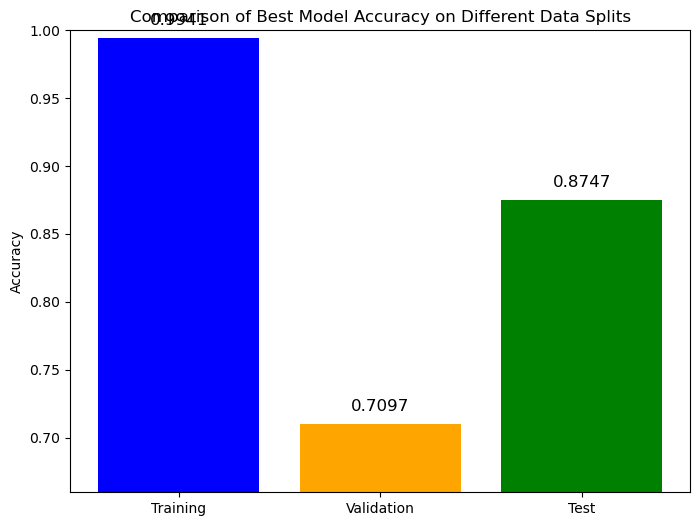

In [47]:
y_test_pred = best_model.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Human Text', 'Generated Text']))

print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'Generated'], yticklabels=['Human', 'Generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

accuracies = {'Training': train_accuracy, 'Validation': val_accuracy, 'Test': test_accuracy}
plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparison of Best Model Accuracy on Different Data Splits')
plt.ylim([min(accuracies.values()) - 0.05, 1.0])
for i, (key, value) in enumerate(accuracies.items()):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center', fontsize=12)
plt.show()

**Final Correct manual group splitting, where all train, test and validation are balanced, close to the 70/20/10 split, without data leakage**

In [48]:
df1 = pd.read_csv("train_v2_drcat_02.csv")

In [49]:
df1.head()

,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False


In [53]:
# manual group assignment ---
print("\n" + "="*60)
print("Step 1: Loading and Splitting Data (Granular Manual Group Split)")
print("="*60)

df = pd.read_csv('merged_dataset(1).csv')

# shuffle first
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# source groups to achieve a ~70/20/10 split
train_sources = [
    'HC3_reddit_eli5',
    'HC3_finance',
    'DAIGT_v2_Distance learning',
    'DAIGT_v2_Seeking multiple opinions',
    'HC3_open_qa'
]

val_sources = [
    'DAIGT_v2_Car-free cities',
    'DAIGT_v2_Does the electoral college work?',
    'DAIGT_v2_Facial action coding system',
    'DAIGT_v2_Mandatory extracurricular activities',
    'DAIGT_v2_Summer projects',
    'HC3_medicine',
    'DAIGT_v2_Driverless cars',
    'DAIGT_v2_Exploring Venus'
]

test_sources = [
    'DAIGT_v2_Cell phones at school',
    'DAIGT_v2_Grades for extracurricular activities',
    'DAIGT_v2_Community service',
    'DAIGT_v2_"A Cowboy Who Rode the Waves"',
    'DAIGT_v2_The Face on Mars',
    'HC3_wiki_csai',
    'DAIGT_v2_Phones and driving'
]

# split DataFrames based on the manually assigned source lists
train_df = df[df['source'].isin(train_sources)]
val_df = df[df['source'].isin(val_sources)]
test_df = df[df['source'].isin(test_sources)]

# final X and y sets for the model
X_train, y_train = train_df['text'].astype(str), train_df['label']
X_val, y_val = val_df['text'].astype(str), val_df['label']
X_test, y_test = test_df['text'].astype(str), test_df['label']

print(f"Total dataset size: {len(df)}")
print(f"Training set size:   {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df):.1%})")
print(f"Test set size:       {len(X_test)} ({len(X_test)/len(df):.1%})")



Step 1: Loading and Splitting Data (Granular Manual Group Split)
Total dataset size: 124195
Training set size:   85897 (69.2%)
Validation set size: 24987 (20.1%)
Test set size:       13311 (10.7%)


In [55]:
print("\n" + "="*60)
print("Step 2: Defining the Model Pipeline and Hyperparameter Grid")
print("="*60)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('clf', LogisticRegression(random_state=42, solver='liblinear')),
])

param_grid = {
    'tfidf__max_features': [15000, 25000, 35000],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}


Step 2: Defining the Model Pipeline and Hyperparameter Grid


In [56]:
# run GridSearchCV
print("\n" + "="*60)
print("Step 3: Running GridSearchCV for Hyperparameter Tuning")
print("="*60)

# 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

start_time = time.time()

grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"\nGridSearchCV finished in {end_time - start_time:.2f} seconds.")



Step 3: Running GridSearchCV for Hyperparameter Tuning
Fitting 5 folds for each of 18 candidates, totalling 90 fits

GridSearchCV finished in 201.04 seconds.


In [57]:
# GridSearchCV results
print("\n" + "="*60)
print("Step 4: Analyzing Hyperparameter Tuning Results")
print("="*60)

print("Best parameters found on the training set:")
print(grid_search.best_params_)

# detailed results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    'param_tfidf__max_features', 'param_clf__C', 'param_clf__penalty',
    'mean_fit_time', 'mean_score_time', 'mean_test_score'
]].rename(columns={
    'param_tfidf__max_features': 'max_features',
    'param_clf__C': 'C',
    'param_clf__penalty': 'penalty',
    'mean_fit_time': 'Avg Train Time (s)',
    'mean_score_time': 'Avg Inference Time (s)',
    'mean_test_score': 'Cross-Val Accuracy'
}).sort_values(by='Cross-Val Accuracy', ascending=False)

print("\n--- Detailed Performance for Each Hyperparameter Configuration ---")
print(results_df)



Step 4: Analyzing Hyperparameter Tuning Results
Best parameters found on the training set:
{'clf__C': 10, 'clf__penalty': 'l2', 'tfidf__max_features': 35000}

--- Detailed Performance for Each Hyperparameter Configuration ---
    max_features     C penalty  Avg Train Time (s)  Avg Inference Time (s)  \
17         35000  10.0      l2           23.457171                1.909351   
16         25000  10.0      l2           24.101261                1.946486   
15         15000  10.0      l2           29.701634                2.349778   
14         35000  10.0      l1           30.596403                2.606485   
13         25000  10.0      l1           30.123843                2.846582   
12         15000  10.0      l1           29.919043                2.584774   
11         35000   1.0      l2           28.342077                2.764173   
10         25000   1.0      l2           27.449747                2.820695   
9          15000   1.0      l2           27.713418                2.402

In [58]:
#best model evaluation on all splits
print("\n" + "="*60)
print("Step 5: Evaluating Final Model Performance")
print("="*60)

# The best_estimator_ is the pipeline refit on the entire training set with the best parameters.
best_model = grid_search.best_estimator_

# Calculate accuracy on all three data splits
train_accuracy = best_model.score(X_train, y_train)
val_accuracy = best_model.score(X_val, y_val)
test_accuracy = best_model.score(X_test, y_test)

print(f"Training Set Accuracy:   {train_accuracy:.4f}")
print(f"Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Test Set Accuracy:       {test_accuracy:.4f} 


Step 5: Evaluating Final Model Performance
Training Set Accuracy:   0.9922
Validation Set Accuracy: 0.8713
Test Set Accuracy:       0.8287  <-- This is your most important score!



Step 6: Generating Final Reports and Plots

Classification Report (Test Set):
                precision    recall  f1-score   support

    Human Text       0.93      0.83      0.88      9717
Generated Text       0.64      0.82      0.72      3594

      accuracy                           0.83     13311
     macro avg       0.78      0.83      0.80     13311
  weighted avg       0.85      0.83      0.83     13311


Confusion Matrix (Test Set):


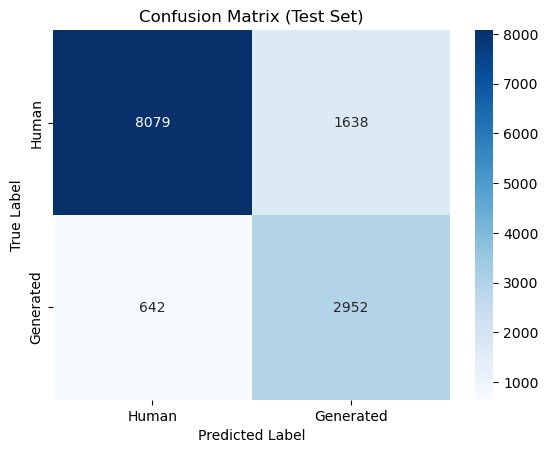

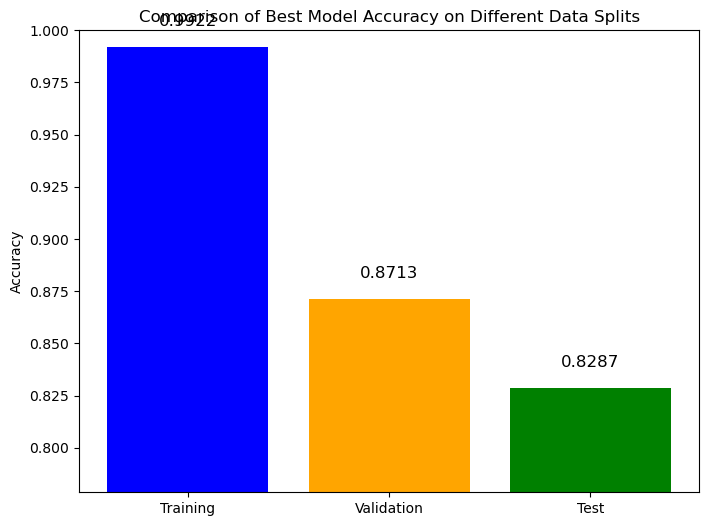

In [59]:
print("\n" + "="*60)
print("Step 6: Generating Final Reports and Plots")
print("="*60)

y_test_pred = best_model.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Human Text', 'Generated Text']))

print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'Generated'], yticklabels=['Human', 'Generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

accuracies = {'Training': train_accuracy, 'Validation': val_accuracy, 'Test': test_accuracy}
plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparison of Best Model Accuracy on Different Data Splits')
plt.ylim([min(accuracies.values()) - 0.05, 1.0])
for i, (key, value) in enumerate(accuracies.items()):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center', fontsize=12)
plt.show()

In [61]:
#testing new sentences manually
print("\n---Testing Model Inference on New Sentences ---")

sentences_to_test = [
    "You don’t need to completely avoid using your credit card to improve your debt-to-income ratio; what actually matters is lowering your monthly debt payments. If your credit card balance is paid in full each month, your DTI won’t be affected, so normal use is fine. But if you tend to carry a balance, limiting credit card spending can help reduce your minimum payments over time, which directly improves your DTI.", # Likely Human
    "Purpose: Used to tune the model's hyperparameters (settings not learned during training, like learning rate, number of layers, or regularization strength) and for model selection (e.g., deciding the optimal number of training epochs).", # Likely Generated
    "ts all about fucking around and findout what, that debian wont give tho some debian distros are pretty good on itself, nix and arch is flexible for ricing.", # Likely Human
    "The underlying architecture of the system is predicated on a decentralized, blockchain-based ledger for enhanced security.", # Likely Generated
    "Linux ricing is all about customizing your Linux desktop to reflect your personal aesthetic and workflow, turning a standard environment into something uniquely yours. It often involves tweaking window managers, themes, icons, fonts, and system behavior to achieve a clean, efficient, or visually striking setup. While some people rice for pure visual flair and others for productivity, the process itself becomes a creative hobby—one that blends technical tinkering with design. In the end, ricing isn’t just about making your system look good; it’s about building a setup that feels right every time you sit down to use it.", # Likely Human
    "I think ricing is not done by watching a 'complete linux ricing guide'. You see a lock screen in r/unixporn and the comments will say it's hyprlock. Now you'll install hyprlock but the default version sucks ass. So you copy the config files from the guy. Turns out he added some dependencies like fonts and icons that you too need to get. You'll do all these and actually get a lockscreen pretty similar. Now you think to yourself the current one isn't actually how i want it to be you now actually read the config fike and search what the various variables do. You tinker with them a lot and will eventually be satisfied. Rinse and repeat.", # Clearly Generated
    "Nurbek is the gayest person in this room."
]

# Use the best model (pipeline) to predict labels and probabilities
predictions = best_model.predict(sentences_to_test)
probabilities = best_model.predict_proba(sentences_to_test)

# Map numeric labels to human-readable names
label_map = {0: 'Human Text', 1: 'Generated Text'}

# Display the results
for i, sentence in enumerate(sentences_to_test):
    predicted_label = label_map[predictions[i]]
    confidence_human = probabilities[i][0]
    confidence_generated = probabilities[i][1]
    
    print(f"\nText: \"{sentence}\"")
    print(f"  -> Predicted Label: {predicted_label}")
    print(f"     Confidence Scores: [Human: {confidence_human:.2%}] [Generated: {confidence_generated:.2%}]")


--- Testing Model Inference on New Sentences ---

Text: "You don’t need to completely avoid using your credit card to improve your debt-to-income ratio; what actually matters is lowering your monthly debt payments. If your credit card balance is paid in full each month, your DTI won’t be affected, so normal use is fine. But if you tend to carry a balance, limiting credit card spending can help reduce your minimum payments over time, which directly improves your DTI."
  -> Predicted Label: Human Text
     Confidence Scores: [Human: 68.39%] [Generated: 31.61%]

Text: "Purpose: Used to tune the model's hyperparameters (settings not learned during training, like learning rate, number of layers, or regularization strength) and for model selection (e.g., deciding the optimal number of training epochs)."
  -> Predicted Label: Human Text
     Confidence Scores: [Human: 56.60%] [Generated: 43.40%]

Text: "ts all about fucking around and findout what, that debian wont give tho some debian distr

In [52]:
import pandas as pd

csv_filename = 'merged_dataset(1).csv'

print(f"Loading dataset from '{csv_filename}'...")
df1 = pd.read_csv(csv_filename)
print("Dataset loaded successfully.")
print("\n--- Number of Rows per Source ---")
source_counts = df1['source'].value_counts()

print(source_counts)

Loading dataset from 'merged_dataset(1).csv'...
Dataset loaded successfully.

--- Number of Rows per Source ---
source
HC3_reddit_eli5                                   62085
HC3_finance                                        8393
DAIGT_v2_Distance learning                         5554
DAIGT_v2_Seeking multiple opinions                 5176
DAIGT_v2_Car-free cities                           4716
HC3_open_qa                                        4689
DAIGT_v2_Does the electoral college work?          4432
DAIGT_v2_Facial action coding system               3084
DAIGT_v2_Mandatory extracurricular activities      3077
DAIGT_v2_Summer projects                           2701
HC3_medicine                                       2551
DAIGT_v2_Driverless cars                           2250
DAIGT_v2_Exploring Venus                           2176
DAIGT_v2_Cell phones at school                     2119
DAIGT_v2_Grades for extracurricular activities     2116
DAIGT_v2_Community service               